1. Given a list of tuples representing raw orders: (Order_ID, Customer_ID, Category, Amount, Status).

Tasks:

Deduplicate: Remove duplicate orders based on Order_ID.

Filtering: Keep only orders where Status == "Completed".

Aggregation: Calculate the total revenue and average spending per Customer_ID.

Categorization: Identify the highest single order amount for each Category.

In [28]:
from collections import defaultdict

orders = [
    (501, 'C10', 'Tech', 1200, 'Completed'),
    (502, 'C11', 'Home', 150, 'Cancelled'),
    (503, 'C10', 'Tech', 800, 'Completed'),
    (501, 'C10', 'Tech', 1200, 'Completed'),  
    (504, 'C12', 'Apparel', 300, 'Completed'),
    (505, 'C11', 'Home', 450, 'Completed'),
]

# 1
unique_orders = {}
for oid, cid, cat, amt, status in orders:
    if oid not in unique_orders:
        unique_orders[oid] = (cid, cat, amt, status)
print('Unique orders: ',unique_orders)

# 2 & 3
customer_spend = defaultdict(list)
category_max = {}

for oid, (cid, cat, amt, status) in unique_orders.items():
    if status == 'Completed':
        customer_spend[cid].append(amt)

        # 4
        if cat not in category_max or amt > category_max[cat]:
            category_max[cat] = amt

print('Customer Summary (Total, Avg):')
for cid, amounts in customer_spend.items():
    print(f'Customer {cid}: Total = ${sum(amounts)}, Avg = ${sum(amounts)/len(amounts):.2f}')

print('\nMax Amount per Category:', category_max)

Unique orders:  {501: ('C10', 'Tech', 1200, 'Completed'), 502: ('C11', 'Home', 150, 'Cancelled'), 503: ('C10', 'Tech', 800, 'Completed'), 504: ('C12', 'Apparel', 300, 'Completed'), 505: ('C11', 'Home', 450, 'Completed')}
Customer Summary (Total, Avg):
Customer C10: Total = $2000, Avg = $1000.00
Customer C12: Total = $300, Avg = $300.00
Customer C11: Total = $450, Avg = $450.00

Max Amount per Category: {'Tech': 1200, 'Apparel': 300, 'Home': 450}


Create an abstract base class Person with a method get_role(). Derive Student and Teacher classes:
Student: Has attributes student_id and gpa.
Teacher: Has attributes emp_id and salary.
Override get_details() to demonstrate polymorphism and print attributes securely

In [9]:
from abc import ABC, abstractmethod

class Person:
    @abstractmethod
    def get_role(self):
        pass
    def get_details(self):
        pass

class Student(Person):
    def __init__(self, student_id,gpa):
        self.student_id = student_id
        self.__gpa = gpa

    def get_role(self):
        print("This is a student")

    def get_details(self):
        print('Student ID: ',self.student_id)
        print('Student GPA: ',self.get_gpa())

    def get_gpa(self):
        return self.__gpa

    def set_gpa(self,gpa):
        self.__gpa = gpa

class Employee(Person):
    def __init__(self, emp_id,salary):
        self.emp_id = emp_id
        self.__salary = salary

    def get_role(self):
        print("This is an employee")

    def get_details(self):
        print('Employee ID: ',self.emp_id)
        print('Employee salary: ',self.get_salary())

    def get_salary(self):
        return self.__salary

    def set_salary(self,salary):
        self.__salary = salary

s = Student(101,3.98)
e = Employee('e11',30000)
s.get_role()
e.get_role()

s.get_details()
e.get_details()

s.set_gpa(3.89)
e.set_salary(50000)

s.get_details()
e.get_details()

This is a student
This is an employee
Student ID:  101
Student GPA:  3.98
Employee ID:  e11
Employee salary:  30000
Student ID:  101
Student GPA:  3.89
Employee ID:  e11
Employee salary:  50000


Given a $4 \times 4$ NumPy array representing quarterly sales performance for 4 employees:Calculate the total and average performance for each employee across all quarters.Find the quarter with the highest overall performance score.Identify employees who maintained a score $> 75$ in every quarter.Normalize the matrix so all values fall between 0 and 1: $X_{\text{norm}} = \frac{X - X_{\min}}{X_{\max} - X_{\min}}$.

In [21]:
import numpy as np
import random

random.seed(42)
arr = np.array(np.random.randint(40,100,16))
arr = arr.reshape(4,4)
print(arr)
name = ['Rahim','Karim','Sumon','Latif']

print('Total performance by each employee: ',np.sum(arr,axis=1))
print('Average performance by each employee: ',np.mean(arr, axis=1))

highestPerformance = np.sum(arr, axis=0)
maximum = np.argmax(highestPerformance)
print("Highest quarterly performance: Quarter ", maximum+1)

emp = np.all(arr > 75, axis=1)
print('Employees with score>75: ',np.array(name)[emp])

norm = (arr-np.min(arr)) / (np.max(arr)-np.min(arr))
print(f'Normalized Matrix: {norm}')

[[52 50 95 77]
 [41 88 73 69]
 [96 65 87 99]
 [60 97 51 61]]
Total performance by each employee:  [274 271 347 269]
Average performance by each employee:  [68.5  67.75 86.75 67.25]
Highest quarterly performance: Quarter  3
Employees with score>75:  []
Normalized Matrix: [[0.18965517 0.15517241 0.93103448 0.62068966]
 [0.         0.81034483 0.55172414 0.48275862]
 [0.94827586 0.4137931  0.79310345 1.        ]
 [0.32758621 0.96551724 0.17241379 0.34482759]]


Create a Pandas DataFrame from a dictionary and perform data manipulation tasks

In [24]:
import pandas as pd

data = {
    'Emp_ID': [101, 102, 103, 104, 105],
    'Name': ['Sarah', 'John', 'Anna', 'Mike', 'Emma'],
    'Department': ['Sales', 'IT', 'Sales', 'HR', 'IT'],
    'Salary': [60000, 85000, 62000, 50000, 90000],
    'Experience_Yrs': [3, 7, 4, 2, 8],
}

df = pd.DataFrame(data)

# 1. Average salary per department
avg_sal = df.groupby('Department')['Salary'].mean()
print('Average Salary per Dept:\n', avg_sal)

# 2. Add 'Bonus' column (15% if Experience > 5 else 5%)
df['Bonus'] = df['Experience_Yrs'].apply(
    lambda x: x * 0.15 if x > 5 else x * 0.05
)
df['Total_Comp'] = df['Salary'] + (df['Salary'] * df['Bonus'])

# 3. Find the highest-paid employee in IT
it_top = df[df['Department'] == 'IT'].sort_values('Salary', ascending=False).iloc[0]
print(f"\nHighest paid in IT: {it_top['Name']} ({it_top['Salary']})")

print('\nUpdated DataFrame:\n', df)

Average Salary per Dept:
 Department
HR       50000.0
IT       87500.0
Sales    61000.0
Name: Salary, dtype: float64

Highest paid in IT: Emma (90000)

Updated DataFrame:
    Emp_ID   Name Department  Salary  Experience_Yrs  Bonus  Total_Comp
0     101  Sarah      Sales   60000               3   0.15     69000.0
1     102   John         IT   85000               7   1.05    174250.0
2     103   Anna      Sales   62000               4   0.20     74400.0
3     104   Mike         HR   50000               2   0.10     55000.0
4     105   Emma         IT   90000               8   1.20    198000.0


Create a subplot grid comparing company metrics using line charts, bar plots, histograms, and pie charts.

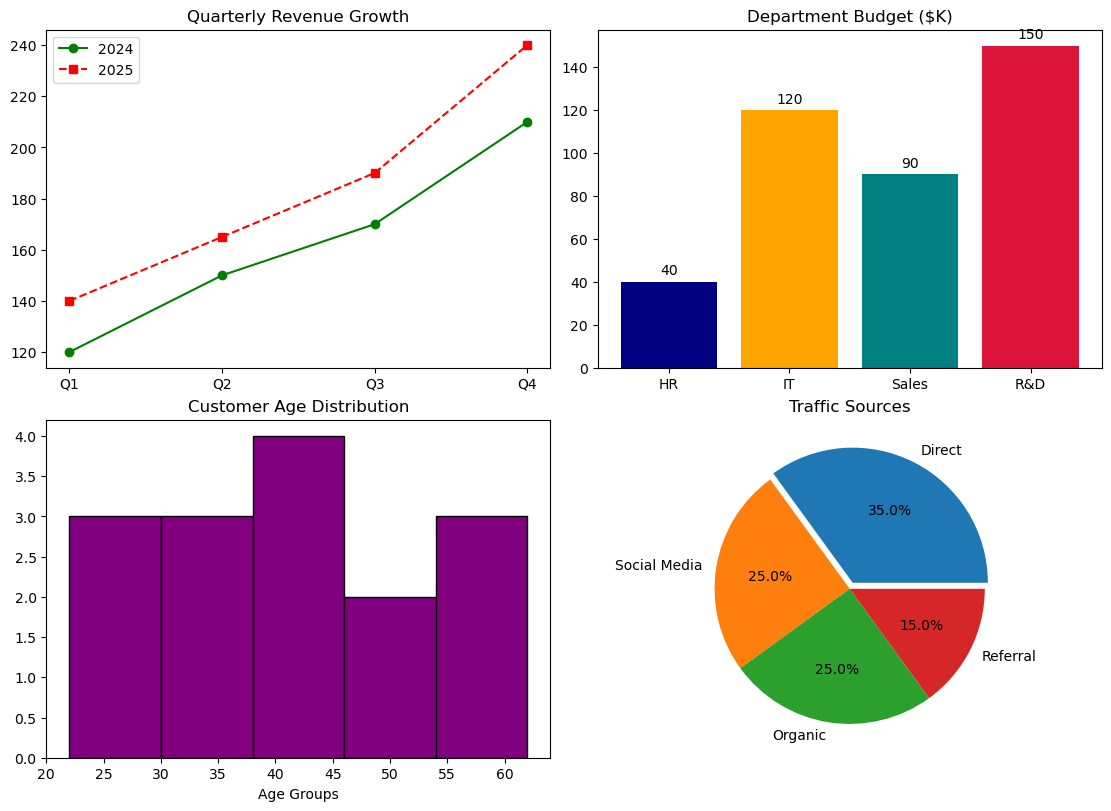

In [27]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)

# 1. Line Plot - Quarterly Revenue Trends
quarters = ['Q1', 'Q2', 'Q3', 'Q4']
rev_2024 = [120, 150, 170, 210]
rev_2025 = [140, 165, 190, 240]
x = np.arange(len(quarters))

ax[0, 0].plot(x, rev_2024, 'g-o', label='2024')
ax[0, 0].plot(x, rev_2025, 'r--s', label='2025')
ax[0, 0].set_xticks(x, quarters)
ax[0, 0].set_title('Quarterly Revenue Growth')
ax[0, 0].legend()

# 2. Bar Plot with Data Labels - Department Budget Allocation
depts = ['HR', 'IT', 'Sales', 'R&D']
budget = [40, 120, 90, 150]
bars = ax[0, 1].bar(depts, budget, color=['navy', 'orange', 'teal', 'crimson'])
ax[0, 1].bar_label(bars, padding=3)
ax[0, 1].set_title('Department Budget ($K)')

# 3. Histogram - Customer Age Distribution
ages = [22, 25, 25, 30, 32, 35, 38, 41, 42, 45, 50, 52, 55, 60, 62]
ax[1, 0].hist(ages, bins=5, color='purple', edgecolor='black')
ax[1, 0].set_title('Customer Age Distribution')
ax[1, 0].set_xlabel('Age Groups')

# 4. Pie Chart - Traffic Sources
sources = ['Direct', 'Social Media', 'Organic', 'Referral']
shares = [35, 25, 25, 15]
ax[1, 1].pie(
    shares, labels=sources, autopct='%1.1f%%', explode=[0.05, 0, 0, 0]
)
ax[1, 1].set_title('Traffic Sources')

plt.show()

Write a script that attempts to open a text log file, count line occurrences containing specific keywords (ERROR, WARNING), and handle exceptions gracefully (FileNotFoundError, PermissionError)

In [30]:
def parse_log_file(filename):
    counts = {'ERROR': 0, 'WARNING': 0, 'INFO': 0}
    try:
        with open(filename, 'r') as f:
            for line in f:
                for key in counts:
                    if key in line:
                        counts[key] += 1
        print('Summary:', counts)

    except FileNotFoundError:
        print(f"Error: The file '{filename}' was not found.")
    except PermissionError:
        print(f"Error: Permission denied when accessing '{filename}'.")
    except Exception as e:
        print(f'An unexpected error occurred: {e}')
    else:
        print('Log parsing completed successfully.')


filename = input('Enter file name: ')
parse_log_file(filename)

Enter file name:  demo.txt


Error: The file 'demo.txt' was not found.
